# Customer Churn Exploratory Data Analysis

This notebook explores the Telco customer churn dataset before modeling. It creates a stratified train/test split immediately after loading the file, then uses only the training set for EDA so the test set remains untouched for final model evaluation.

## 1. Import Libraries


In [50]:
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

sns.set_theme(style="whitegrid", palette="Set2")

## 2. Load Dataset and Create Train/Test Split

In [51]:
DATA_PATH = Path("data/Telco_customer_churn.xlsx")

TEST_SIZE = 0.20
RANDOM_STATE = 42
TARGET_COLUMN = "Churn Value"

df = pd.read_excel(DATA_PATH)

train_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df[TARGET_COLUMN],
)

# Use only the training data for EDA-driven modeling decisions.
eda_df = train_df.copy()

split_summary = pd.DataFrame(
    {
        "rows": [len(df), len(train_df), len(test_df)],
        "churn_rate": [
            df[TARGET_COLUMN].mean(),
            train_df[TARGET_COLUMN].mean(),
            test_df[TARGET_COLUMN].mean(),
        ],
    },
    index=["full_data", "train", "test"],
)

display(split_summary)
eda_df.head()

,rows,churn_rate
full_data,7043,0.27
train,5634,0.27
test,1409,0.27


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
4626,4950-BDEUX,1,United States,California,Apple Valley,92308,"34.424926, -117.184503",34.42,-117.18,Male,No,No,No,35,No,No phone service,DSL,No,No,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,49.20,1701.65,No,0,40,2782,NaN
4192,7993-NQLJE,1,United States,California,Glenn,95943,"39.597975, -122.032248",39.60,-122.03,Male,No,Yes,Yes,15,Yes,No,Fiber optic,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,75.10,1151.55,No,0,60,4634,NaN
5457,7321-ZNSLA,1,United States,California,Cottonwood,96022,"40.336392, -122.448533",40.34,-122.45,Male,No,Yes,Yes,13,No,No phone service,DSL,Yes,Yes,No,Yes,No,No,Two year,No,Mailed check,40.55,590.35,No,0,27,2898,NaN
4717,4922-CVPDX,1,United States,California,Westminster,92683,"33.752591, -117.993661",33.75,-117.99,Female,No,Yes,No,26,Yes,No,DSL,No,Yes,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),73.50,1905.70,No,0,67,3596,NaN
4673,2903-YYTBW,1,United States,California,Hemet,92545,"33.734933, -117.044145",33.73,-117.04,Male,No,Yes,Yes,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,No,Electronic check,44.55,44.55,No,0,48,3408,NaN


## 3. Training Set Overview

In [52]:
print(f"Training rows: {eda_df.shape[0]:,}")
print(f"Training columns: {eda_df.shape[1]:,}")

eda_df.info()

Training rows: 5,634
Training columns: 33
<class 'pandas.core.frame.DataFrame'>
Index: 5634 entries, 4626 to 6017
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         5634 non-null   object 
 1   Count              5634 non-null   int64  
 2   Country            5634 non-null   object 
 3   State              5634 non-null   object 
 4   City               5634 non-null   object 
 5   Zip Code           5634 non-null   int64  
 6   Lat Long           5634 non-null   object 
 7   Latitude           5634 non-null   float64
 8   Longitude          5634 non-null   float64
 9   Gender             5634 non-null   object 
 10  Senior Citizen     5634 non-null   object 
 11  Partner            5634 non-null   object 
 12  Dependents         5634 non-null   object 
 13  Tenure Months      5634 non-null   int64  
 14  Phone Service      5634 non-null   object 
 15  Multiple Lines     5634 non-null

In [53]:
eda_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,5634,5634,4950-BDEUX,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Count,5634.00,NaN,NaN,NaN,1.00,0.00,1.00,1.00,1.00,1.00,1.00
Country,5634,1,United States,5634,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,5634,1,California,5634,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,5634,1128,Los Angeles,250,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zip Code,5634.00,NaN,NaN,NaN,93507.79,1869.18,90001.00,92072.00,93545.00,95346.00,96161.00
Lat Long,5634,1650,"34.015481, -118.493231",5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latitude,5634.00,NaN,NaN,NaN,36.27,2.46,32.56,34.03,36.32,38.20,41.96
Longitude,5634.00,NaN,NaN,NaN,-119.79,2.16,-124.30,-121.80,-119.69,-118.03,-114.19
Gender,5634,2,Male,2833,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Training Set Missing Values and Duplicates

In [54]:
missing_summary = (
    eda_df.isna().sum()
    .to_frame("missing_count")
    .assign(missing_percent=lambda x: x["missing_count"] / len(eda_df) * 100)
    .query("missing_count > 0")
    .sort_values("missing_count", ascending=False)
)

missing_summary

,missing_count,missing_percent
Churn Reason,4139,73.46


In [55]:
blank_counts = (
    eda_df.select_dtypes(include="object")
    .apply(lambda col: col.astype(str).str.strip().eq("").sum())
    .sort_values(ascending=False)
)

blank_counts[blank_counts > 0]

Total Charges    8
dtype: int64

In [56]:
print(f"Duplicate training rows: {eda_df.duplicated().sum():,}")
print(f"Duplicate training customer IDs: {eda_df['CustomerID'].duplicated().sum():,}")

Duplicate training rows: 0
Duplicate training customer IDs: 0


## 5. Target Variable: Churn in the Training Set

In [57]:
churn_counts = eda_df["Churn Label"].value_counts()
churn_rate = eda_df["Churn Value"].mean()

print(churn_counts)
print(f"\nTraining churn rate: {churn_rate:.2%}")

Churn Label
No     4139
Yes    1495
Name: count, dtype: int64

Training churn rate: 26.54%


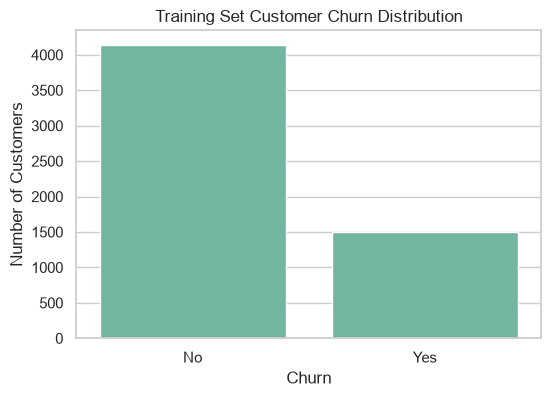

In [58]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=eda_df, x="Churn Label", ax=ax)
ax.set_title("Training Set Customer Churn Distribution")
ax.set_xlabel("Churn")
ax.set_ylabel("Number of Customers")
plt.show()

## 6. Numeric Feature Distributions


In [59]:
numeric_columns = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "Churn Score",
    "CLTV",
]

for column in numeric_columns:
    eda_df[column] = pd.to_numeric(eda_df[column], errors="coerce")

eda_df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Tenure Months,5634.00,32.49,24.57,0.00,9.00,29.00,55.00,72.00
Monthly Charges,5634.00,64.93,30.14,18.40,35.66,70.50,90.00,118.75
Total Charges,5626.00,2302.60,2279.17,18.85,407.27,1398.12,3838.61,8684.80
Churn Score,5634.00,58.67,21.55,5.00,40.00,61.00,75.00,100.00
CLTV,5634.00,4404.10,1182.19,2003.00,3470.25,4528.00,5380.75,6500.00


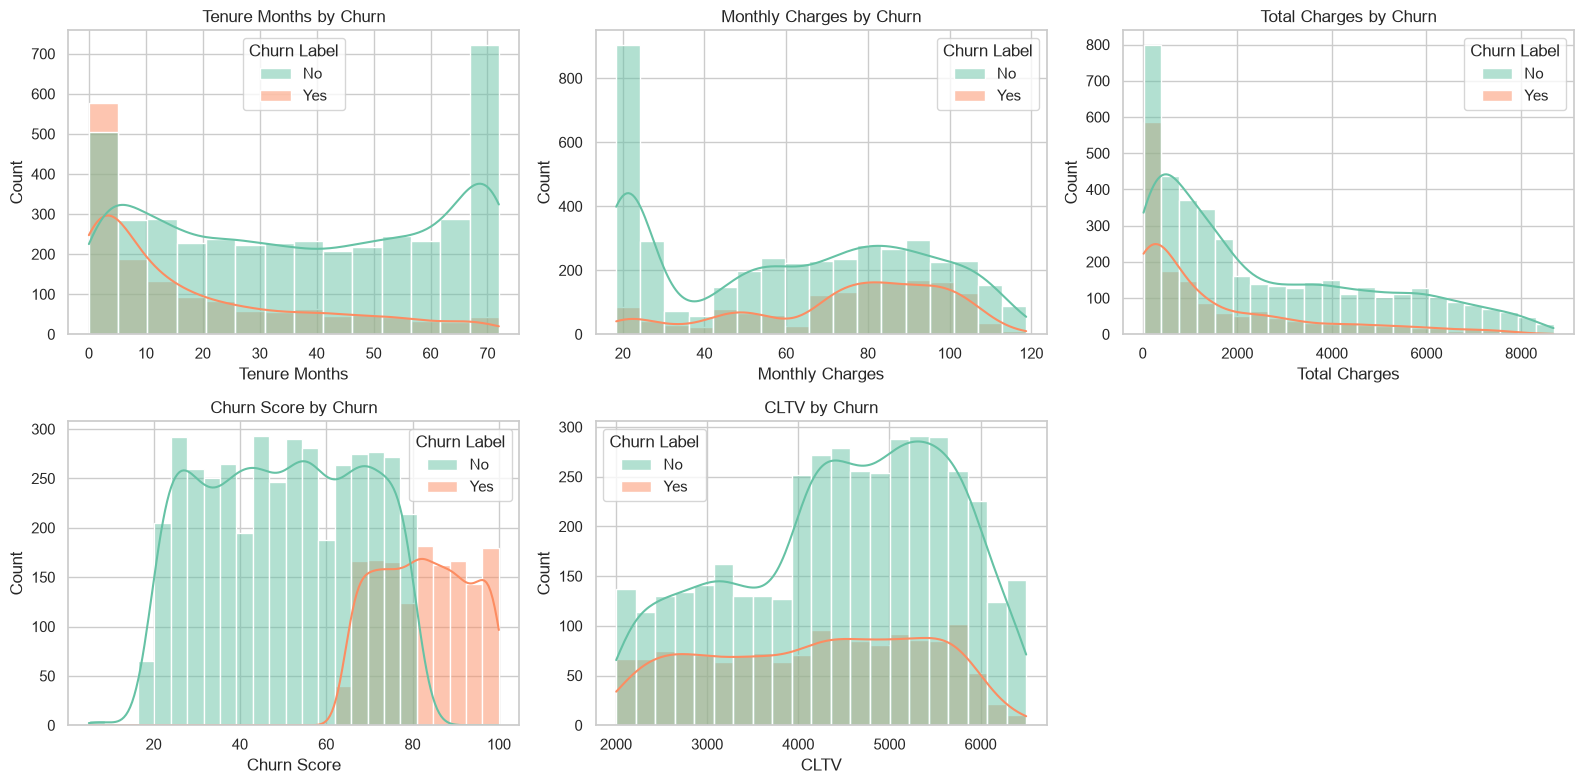

In [60]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, column in zip(axes, numeric_columns):
    sns.histplot(data=eda_df, x=column, hue="Churn Label", kde=True, ax=ax)
    ax.set_title(f"{column} by Churn")

for ax in axes[len(numeric_columns):]:
    ax.remove()

plt.tight_layout()
plt.show()

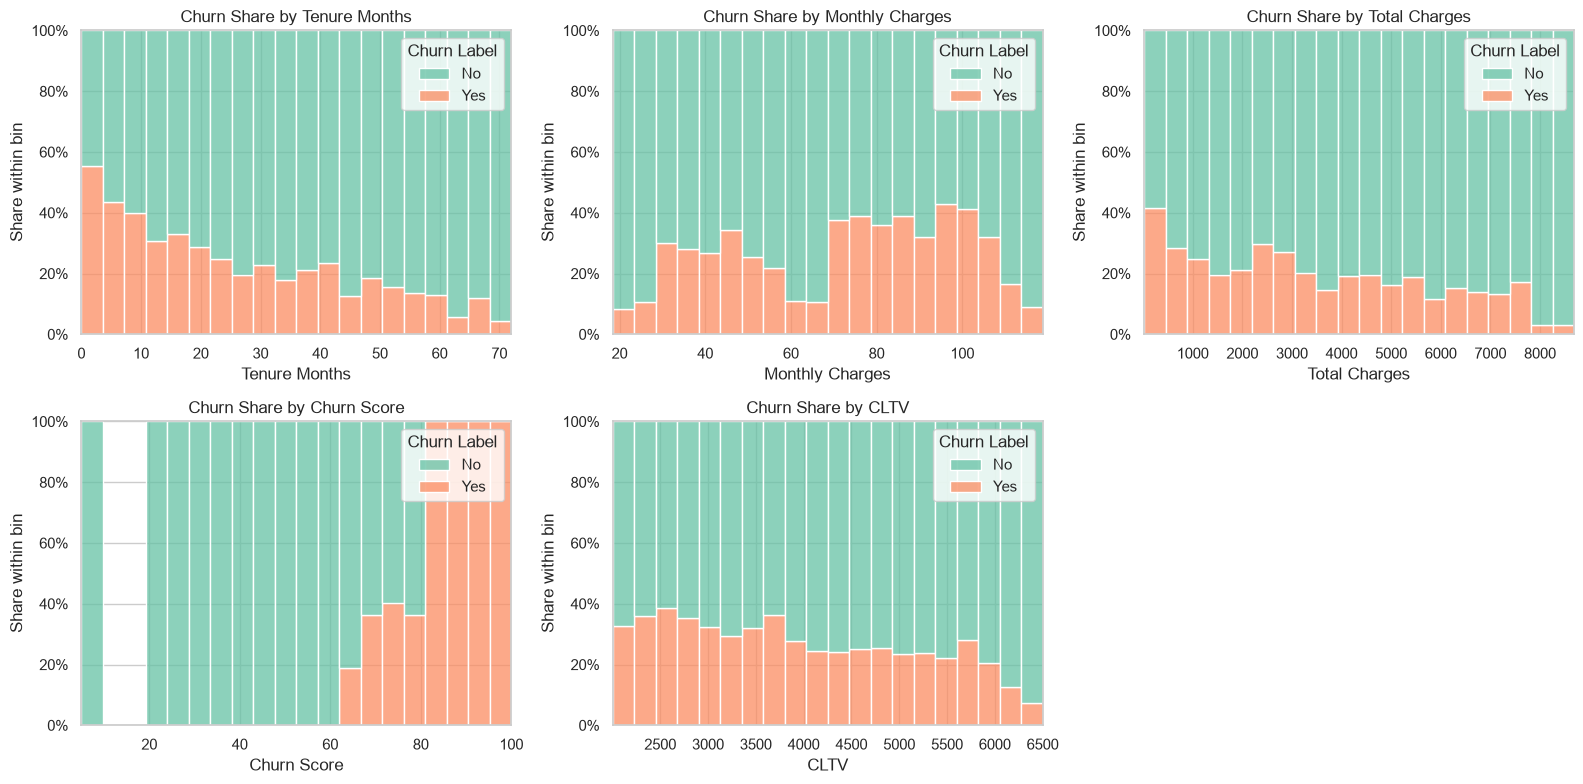

In [61]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, column in zip(axes, numeric_columns):
    sns.histplot(
        data=eda_df,
        x=column,
        hue="Churn Label",
        multiple="fill",
        bins=20,
        ax=ax,
    )
    ax.set_title(f"Churn Share by {column}")
    ax.set_ylabel("Share within bin")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

for ax in axes[len(numeric_columns):]:
    ax.remove()

plt.tight_layout()
plt.show()

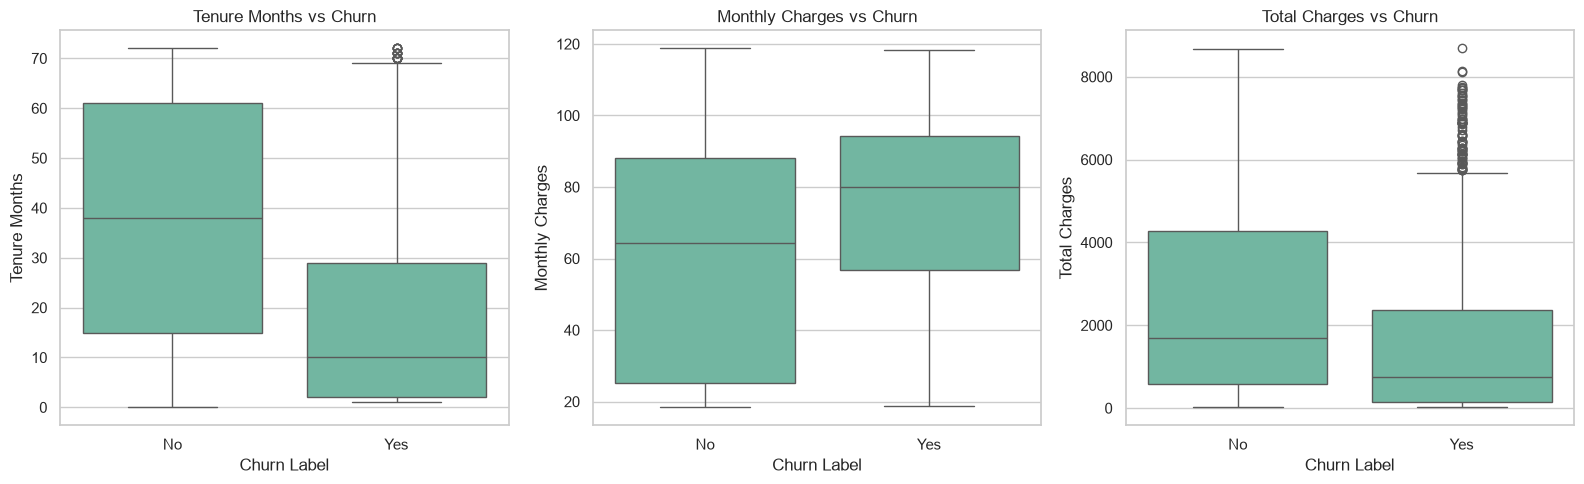

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, column in zip(axes, ["Tenure Months", "Monthly Charges", "Total Charges"]):
    sns.boxplot(data=eda_df, x="Churn Label", y=column, ax=ax)
    ax.set_title(f"{column} vs Churn")

plt.tight_layout()
plt.show()

## 7. Churn by Categorical Features


In [63]:
def plot_churn_rate(column, top_n=None):
    data = eda_df.copy()
    if top_n is not None:
        top_values = data[column].value_counts().head(top_n).index
        data = data[data[column].isin(top_values)]

    churn_by_group = (
        data.groupby(column, dropna=False)["Churn Value"]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(9, 4))
    sns.barplot(data=churn_by_group, x=column, y="Churn Value", ax=ax)
    ax.set_title(f"Training Churn Rate by {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Churn Rate")
    ax.tick_params(axis="x", rotation=35)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    plt.tight_layout()
    plt.show()

    return churn_by_group

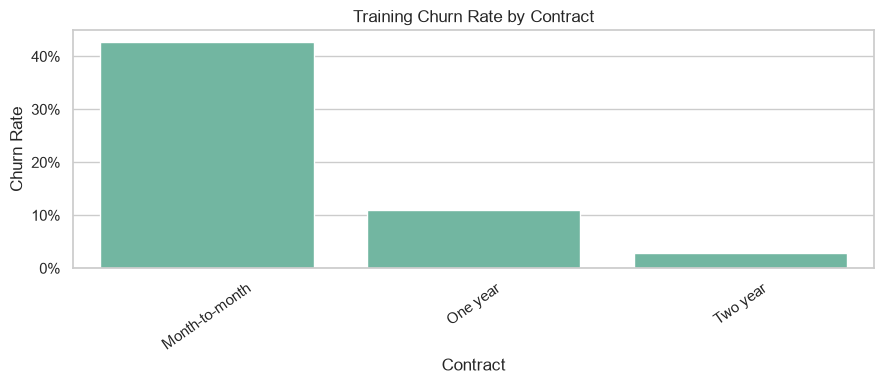

,Contract,Churn Value
0,Month-to-month,0.43
1,One year,0.11
2,Two year,0.03


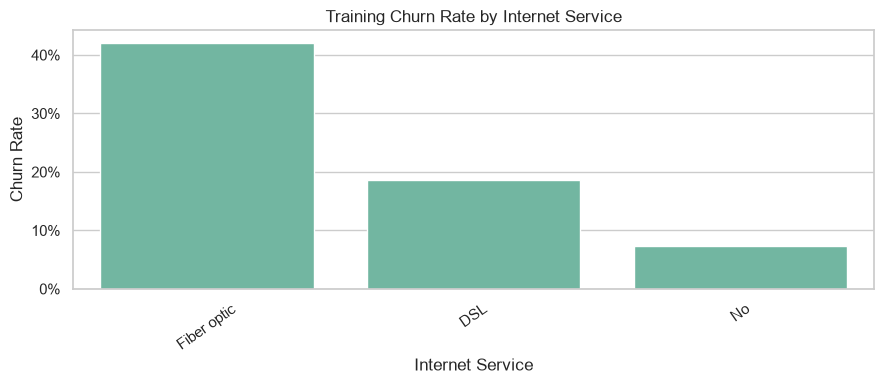

,Internet Service,Churn Value
0,Fiber optic,0.42
1,DSL,0.19
2,No,0.07


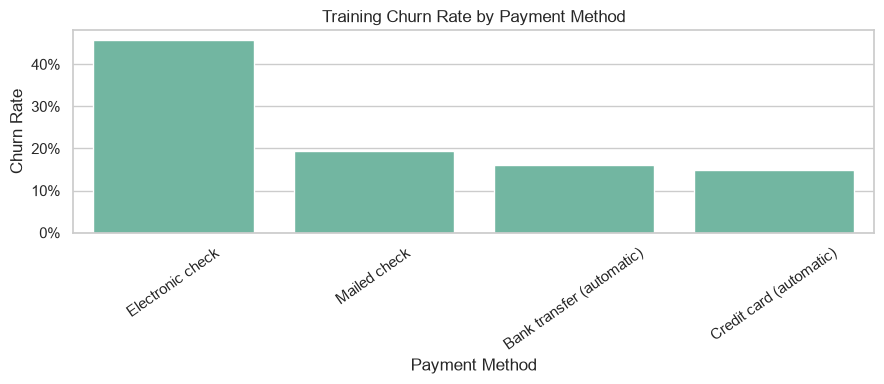

,Payment Method,Churn Value
0,Electronic check,0.46
1,Mailed check,0.19
2,Bank transfer (automatic),0.16
3,Credit card (automatic),0.15


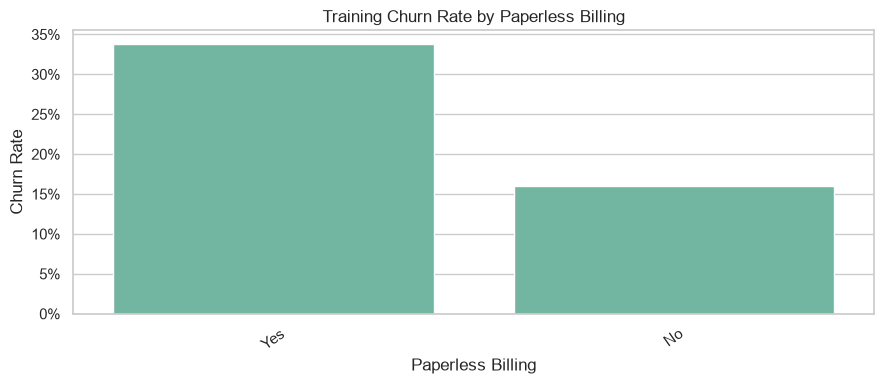

,Paperless Billing,Churn Value
0,Yes,0.34
1,No,0.16


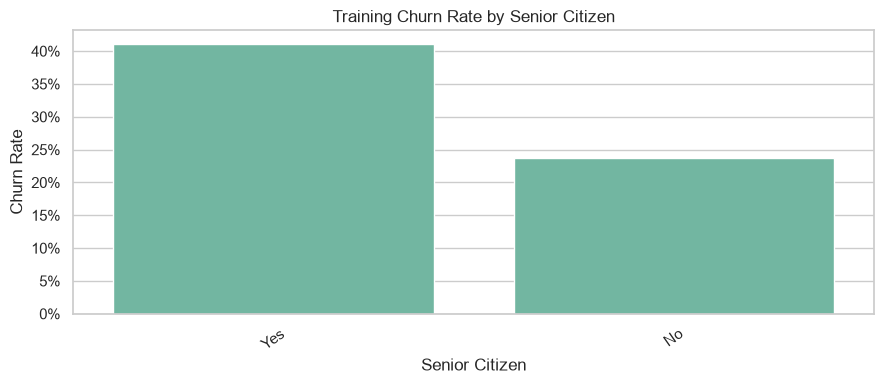

,Senior Citizen,Churn Value
0,Yes,0.41
1,No,0.24


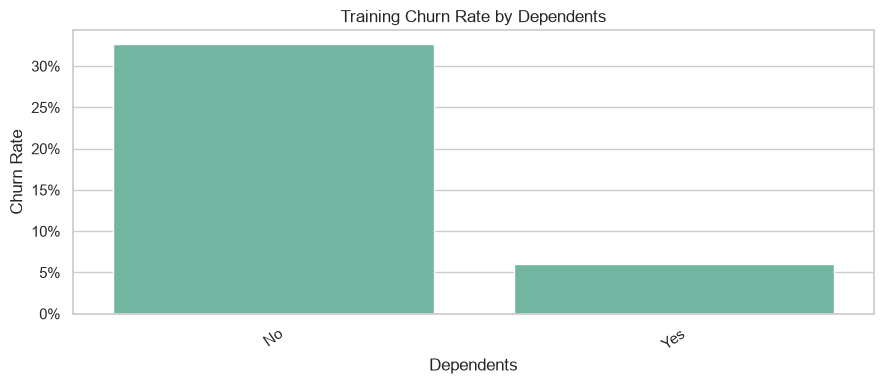

,Dependents,Churn Value
0,No,0.33
1,Yes,0.06


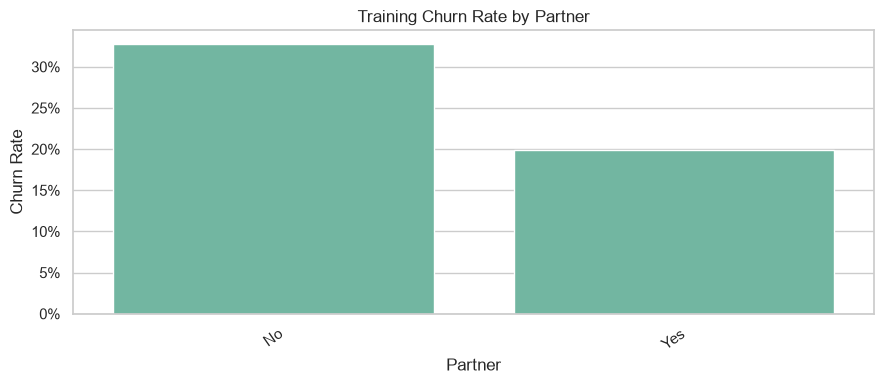

,Partner,Churn Value
0,No,0.33
1,Yes,0.20


In [64]:
for column in [
    "Contract",
    "Internet Service",
    "Payment Method",
    "Paperless Billing",
    "Senior Citizen",
    "Dependents",
    "Partner",
]:
    display(plot_churn_rate(column))


## 8. Training Set Churn Reasons

This section looks only at training-set customers who churned. `Churn Reason` should not be used as a model feature because it is only known after churn happens.

In [65]:
churned = eda_df[eda_df["Churn Value"] == 1]

reason_counts = churned["Churn Reason"].value_counts().head(15)
reason_counts

Churn Reason
Competitor offered higher download speeds    151
Attitude of support person                   146
Competitor offered more data                 129
Don't know                                   119
Competitor made better offer                 114
Attitude of service provider                 112
Competitor had better devices                 97
Product dissatisfaction                       89
Network reliability                           88
Service dissatisfaction                       74
Price too high                                73
Lack of self-service on Website               73
Extra data charges                            45
Moved                                         44
Lack of affordable download/upload speed      36
Name: count, dtype: int64

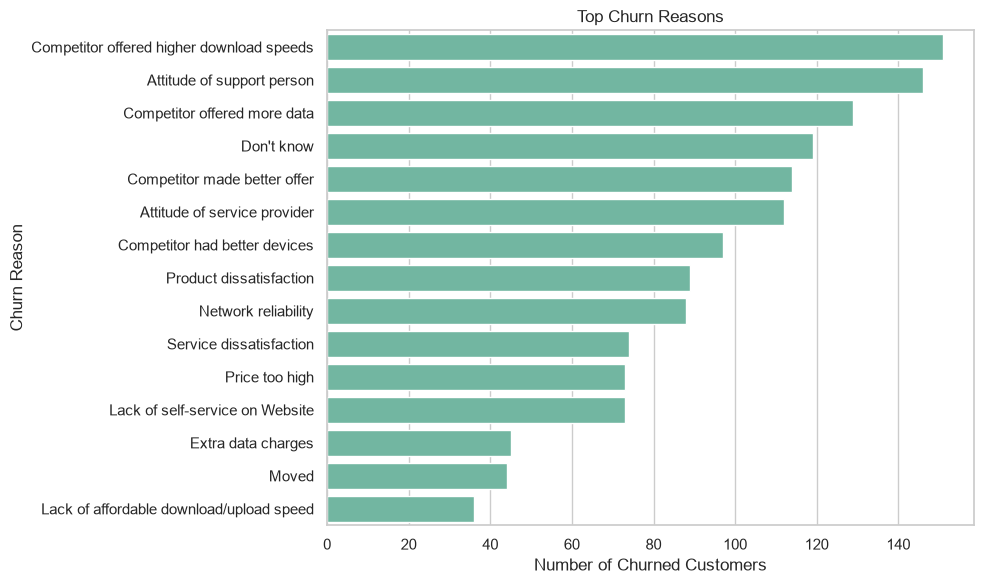

In [66]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=reason_counts.values, y=reason_counts.index, ax=ax)
ax.set_title("Top Churn Reasons")
ax.set_xlabel("Number of Churned Customers")
ax.set_ylabel("Churn Reason")
plt.tight_layout()
plt.show()


## 9. Correlation Between Numeric Features


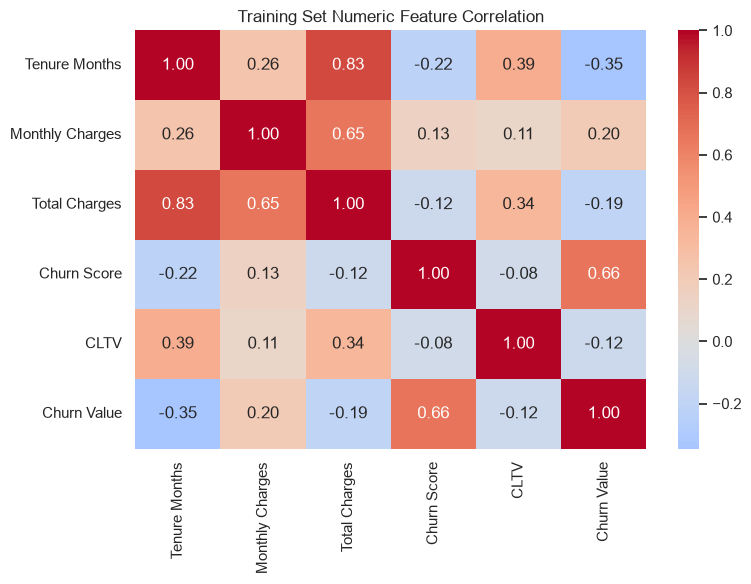

In [67]:
corr_columns = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "Churn Score",
    "CLTV",
    "Churn Value",
]

corr = eda_df[corr_columns].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f", ax=ax)
ax.set_title("Training Set Numeric Feature Correlation")
plt.tight_layout()
plt.show()

## 10. Initial EDA Takeaways

Use this section to write observations after running the notebook. These observations come from the training data only, so the test set remains a clean final evaluation set.

Useful points to check:

- Is churn concentrated in month-to-month contracts?
- Do newer customers churn more often than long-tenure customers?
- Are churn rates higher for specific internet services or payment methods?
- Which fields are leakage columns and should be excluded from modeling?

In [68]:
summary = {
    "training_customers": len(eda_df),
    "training_churned_customers": int(eda_df["Churn Value"].sum()),
    "training_churn_rate": eda_df["Churn Value"].mean(),
    "training_average_monthly_charges": eda_df["Monthly Charges"].mean(),
    "training_median_tenure_months": eda_df["Tenure Months"].median(),
    "held_out_test_customers": len(test_df),
}

pd.Series(summary)

training_customers                 5634.00
training_churned_customers         1495.00
training_churn_rate                   0.27
training_average_monthly_charges     64.93
training_median_tenure_months        29.00
held_out_test_customers            1409.00
dtype: float64